# Transformer from Scratch — English → German Translation
**Dataset:** Multi30k (29,000 image caption pairs, avg 11 words/sentence)  
**Task:** Translate English sentences to German  
**Tokenization:** Word-level with `<PAD>`, `<START>`, `<END>`, `<UNK>`

---
### Notebook Flow
| # | Section |
|---|---------|
| 1 | Imports & Device |
| 2–8 | Architecture (PE → Embedding → Attention → Encoder → Decoder) |
| 9 | Dataset & Vocabulary |
| 10 | DataLoader |
| 11 | Mask Helpers |
| 12 | Model Init |
| 13 | Training Loop |
| 14 | Loss Curve |
| 15 | Inference |
| 16 | BLEU Score |
| 17 | Attention Heatmap |


## 1. Imports & Device

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import math, random, os
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", DEVICE)

Device: cuda


## 2. Positional Encoding
Transformers have no recurrence, so we inject position info using sine/cosine waves.  
Position `pos`, dimension `i`:

$$PE_{(pos,2i)} = \sin\left(\frac{pos}{10000^{2i/d_{model}}}\right), \quad PE_{(pos,2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{model}}}\right)$$


In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_len, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        # Build the fixed PE matrix once
        pe       = torch.zeros(max_seq_len, d_model)
        position = torch.arange(0, max_seq_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float()
                             * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)           # (1, max_seq_len, d_model) — batch dim
        self.register_buffer('pe', pe) # not a parameter, but saved with model

    def forward(self, x):
        # x: (batch, seq_len, d_model)
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

## 3. Scaled Dot-Product Attention

$$\text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

Dividing by $\sqrt{d_k}$ prevents the dot products from growing too large and killing gradients.


In [ ]:
def scaled_dot_product_attention(q, k, v, mask=None):
    d_k      = q.size(-1)
    scores   = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores + mask          # mask contains 0 or -inf
    weights  = F.softmax(scores, dim=-1)
    output   = torch.matmul(weights, v)
    return output, weights

## 4. Multi-Head Attention
Run `num_heads` attention operations in parallel on smaller `head_dim = d_model // num_heads` slices,  
then concatenate and project back.


In [ ]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.head_dim  = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)
        self.attention_weights = None   # stored for visualisation

    def split_heads(self, x):
        # x: (B, S, d_model) → (B, num_heads, S, head_dim)
        B, S, D = x.size()
        x = x.view(B, S, self.num_heads, self.head_dim)
        return x.transpose(1, 2)

    def forward(self, q, k, v, mask=None):
        B = q.size(0)
        q = self.split_heads(self.W_q(q))
        k = self.split_heads(self.W_k(k))
        v = self.split_heads(self.W_v(v))

        out, self.attention_weights = scaled_dot_product_attention(q, k, v, mask)

        # Concat heads → (B, S, d_model)
        out = out.transpose(1, 2).contiguous().view(B, -1, self.num_heads * self.head_dim)
        return self.W_o(out)

## 5. Feed-Forward Network & Layer Normalization
Each position passes through the same 2-layer MLP independently.


In [ ]:
class FeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model)
        )

    def forward(self, x):
        return self.net(x)

## 6. Encoder
Each encoder layer:  
`x → Self-Attention → Add & Norm → FFN → Add & Norm`

The residual connections (`x + sublayer(x)`) help gradients flow during training.


In [ ]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn       = FeedForward(d_model, d_ff, dropout)
        self.norm1     = nn.LayerNorm(d_model)
        self.norm2     = nn.LayerNorm(d_model)
        self.dropout   = nn.Dropout(dropout)

    def forward(self, x, src_mask):
        # Self-attention + residual
        x = self.norm1(x + self.dropout(self.self_attn(x, x, x, src_mask)))
        # FFN + residual
        x = self.norm2(x + self.dropout(self.ffn(x)))
        return x


class Encoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_ff,
                 num_layers, max_seq_len, dropout, pad_idx):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_enc   = PositionalEncoding(d_model, max_seq_len, dropout)
        self.layers    = nn.ModuleList([
            EncoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.scale = math.sqrt(d_model)

    def forward(self, src, src_mask):
        x = self.token_emb(src) * self.scale   # scale embedding
        x = self.pos_enc(x)
        for layer in self.layers:
            x = layer(x, src_mask)
        return x

## 7. Decoder
Each decoder layer has **three** sub-layers:  
1. **Masked** Self-Attention (can't look at future tokens)  
2. **Cross-Attention** — queries come from decoder, keys/values from encoder  
3. FFN

The cross-attention is where the decoder "reads" the source sentence.


In [ ]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super().__init__()
        self.self_attn  = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.ffn        = FeedForward(d_model, d_ff, dropout)
        self.norm1      = nn.LayerNorm(d_model)
        self.norm2      = nn.LayerNorm(d_model)
        self.norm3      = nn.LayerNorm(d_model)
        self.dropout    = nn.Dropout(dropout)

    def forward(self, x, enc_out, tgt_mask, src_mask):
        # 1. Masked self-attention on target
        x = self.norm1(x + self.dropout(self.self_attn(x, x, x, tgt_mask)))
        # 2. Cross-attention: query=decoder, key/value=encoder
        x = self.norm2(x + self.dropout(self.cross_attn(x, enc_out, enc_out, src_mask)))
        # 3. FFN
        x = self.norm3(x + self.dropout(self.ffn(x)))
        return x


class Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_heads, d_ff,
                 num_layers, max_seq_len, dropout, pad_idx):
        super().__init__()
        self.token_emb = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_enc   = PositionalEncoding(d_model, max_seq_len, dropout)
        self.layers    = nn.ModuleList([
            DecoderLayer(d_model, num_heads, d_ff, dropout)
            for _ in range(num_layers)
        ])
        self.fc_out = nn.Linear(d_model, vocab_size)
        self.scale  = math.sqrt(d_model)

    def forward(self, tgt, enc_out, tgt_mask, src_mask):
        x = self.token_emb(tgt) * self.scale
        x = self.pos_enc(x)
        for layer in self.layers:
            x = layer(x, enc_out, tgt_mask, src_mask)
        return self.fc_out(x)

## 8. Full Transformer

In [ ]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size,
                 d_model=256, num_heads=8, d_ff=512,
                 num_layers=3, max_seq_len=100,
                 dropout=0.1, pad_idx=0):
        super().__init__()
        self.encoder = Encoder(src_vocab_size, d_model, num_heads, d_ff,
                               num_layers, max_seq_len, dropout, pad_idx)
        self.decoder = Decoder(tgt_vocab_size, d_model, num_heads, d_ff,
                               num_layers, max_seq_len, dropout, pad_idx)
        self._init_weights()

    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)

    def forward(self, src, tgt, src_mask, tgt_mask):
        enc_out = self.encoder(src, src_mask)
        return self.decoder(tgt, enc_out, tgt_mask, src_mask)

## 9. Dataset & Vocabulary
**Multi30k** — 29,000 English/German sentence pairs describing Flickr images.  
Originally used to benchmark translation models. Short, clean sentences.

We build word-level vocabularies (top 5000 words + 4 special tokens).  
Words outside the vocab → `<UNK>`.


In [ ]:
# ── Download Multi30k (hosted on GitHub) ──────────────────────────────────────
import urllib.request, gzip, os

BASE = "https://raw.githubusercontent.com/multi30k/dataset/master/data/task1/raw"
FILES = {
    "train.en": f"{BASE}/train.en.gz",
    "train.de": f"{BASE}/train.de.gz",
    "val.en"  : f"{BASE}/val.en.gz",
    "val.de"  : f"{BASE}/val.de.gz",
    "test.en" : f"{BASE}/test_2016_flickr.en.gz",
    "test.de" : f"{BASE}/test_2016_flickr.de.gz",
}

os.makedirs("data", exist_ok=True)

for fname, url in FILES.items():
    out = f"data/{fname}"
    if not os.path.exists(out):
        print(f"Downloading {fname}...")
        with urllib.request.urlopen(url) as r, gzip.open(r) as gz, open(out, 'wb') as f:
            f.write(gz.read())

def read_lines(path):
    with open(path) as f:
        return [l.strip().lower() for l in f if l.strip()]

train_en = read_lines("data/train.en")
train_de = read_lines("data/train.de")
val_en   = read_lines("data/val.en")
val_de   = read_lines("data/val.de")
test_en  = read_lines("data/test.en")
test_de  = read_lines("data/test.de")

print(f"Train: {len(train_en):,} pairs")
print(f"Val  : {len(val_en):,} pairs")
print(f"Test : {len(test_en):,} pairs")
print()
print("Sample pairs:")
for i in range(3):
    print(f"  EN: {train_en[i]}")
    print(f"  DE: {train_de[i]}")
    print()

Train: 29,000 pairs
Val  : 1,014 pairs
Test : 1,000 pairs

Sample pairs:
  EN: two young, white males are outside near many bushes.
  DE: zwei junge weiße männer sind im freien in der nähe vieler büsche.

  EN: several men in hard hats are operating a giant pulley system.
  DE: mehrere männer mit schutzhelmen bedienen ein antriebsradsystem.

  EN: a little girl climbing into a wooden playhouse.
  DE: ein kleines mädchen klettert in ein spielhaus aus holz.



In [ ]:
# ── Build Vocabulary ──────────────────────────────────────────────────────────
PAD, START, END, UNK = '<PAD>', '<START>', '<END>', '<UNK>'
SPECIALS = [PAD, START, END, UNK]

def build_vocab(sentences, max_vocab=5000):
    counter = Counter(w for s in sentences for w in s.split())
    words   = [w for w, _ in counter.most_common(max_vocab - len(SPECIALS))]
    vocab   = {w: i for i, w in enumerate(SPECIALS + words)}
    return vocab

src_vocab = build_vocab(train_en, max_vocab=5000)
tgt_vocab = build_vocab(train_de, max_vocab=5000)
idx2tgt   = {i: w for w, i in tgt_vocab.items()}

print(f"Source (EN) vocab size: {len(src_vocab)}")
print(f"Target (DE) vocab size: {len(tgt_vocab)}")

Source (EN) vocab size: 5000
Target (DE) vocab size: 5000


## 10. PyTorch Dataset & DataLoader

In [ ]:
MAX_SEQ_LEN = 50    # sentences longer than this are dropped (very few)

class TranslationDataset(Dataset):
    def __init__(self, src_sentences, tgt_sentences, src_vocab, tgt_vocab, max_len):
        self.pairs = []
        for s, t in zip(src_sentences, tgt_sentences):
            s_tok = s.split()
            t_tok = t.split()
            # +2 for <START>/<END> tokens
            if len(s_tok) + 2 <= max_len and len(t_tok) + 2 <= max_len:
                self.pairs.append((s_tok, t_tok))
        self.src_vocab = src_vocab
        self.tgt_vocab = tgt_vocab

    def encode(self, tokens, vocab):
        ids = [vocab.get(w, vocab[UNK]) for w in tokens]
        return [vocab[START]] + ids + [vocab[END]]

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        src_tok, tgt_tok = self.pairs[idx]
        return (torch.tensor(self.encode(src_tok, self.src_vocab)),
                torch.tensor(self.encode(tgt_tok, self.tgt_vocab)))


def collate_fn(batch):
    """Pad sequences in a batch to the same length."""
    src_batch, tgt_batch = zip(*batch)
    src_pad = nn.utils.rnn.pad_sequence(src_batch, batch_first=True,
                                         padding_value=src_vocab[PAD])
    tgt_pad = nn.utils.rnn.pad_sequence(tgt_batch, batch_first=True,
                                         padding_value=tgt_vocab[PAD])
    return src_pad, tgt_pad


train_ds = TranslationDataset(train_en, train_de, src_vocab, tgt_vocab, MAX_SEQ_LEN)
val_ds   = TranslationDataset(val_en,   val_de,   src_vocab, tgt_vocab, MAX_SEQ_LEN)
test_ds  = TranslationDataset(test_en,  test_de,  src_vocab, tgt_vocab, MAX_SEQ_LEN)

BATCH_SIZE = 128
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f"Train batches : {len(train_loader)}")
print(f"Val   batches : {len(val_loader)}")

Train batches : 227
Val   batches : 8


## 11. Mask Helpers

| Mask | Shape | Purpose |
|------|-------|---------|
| `src_pad_mask` | (B, 1, 1, S) | Hide `<PAD>` tokens in encoder |
| `tgt_causal_mask` | (1, 1, T, T) | Prevent decoder seeing future tokens |
| Combined `tgt_mask` | (B, 1, T, T) | Both padding + causal for decoder |


In [ ]:
def make_src_mask(src, pad_idx):
    """(B, 1, 1, S): -inf where src token is PAD, else 0."""
    mask = (src == pad_idx).unsqueeze(1).unsqueeze(2).float()
    return mask.masked_fill(mask == 1, float('-inf')).to(DEVICE)


def make_tgt_mask(tgt, pad_idx):
    """(B, 1, T, T): combines causal mask + padding mask."""
    T    = tgt.size(1)
    # Causal mask: upper triangle = -inf
    causal = torch.triu(torch.ones(T, T), diagonal=1).bool()
    causal = causal.unsqueeze(0).unsqueeze(0).to(DEVICE)       # (1,1,T,T)
    # Padding mask
    pad_m  = (tgt == pad_idx).unsqueeze(1).unsqueeze(2).to(DEVICE)  # (B,1,1,T)
    # Combine: either causal OR padding position → -inf
    combined = (causal | pad_m).float()
    return combined.masked_fill(combined == 1, float('-inf'))

## 12. Model, Optimizer & Scheduler

We use **label smoothing** (0.1) — distributes 10% of probability mass to non-target tokens.  
This prevents overconfident predictions and improves generalisation.

**Learning rate warmup** (Noam scheduler from the original paper) ramps LR up for the first N steps then decays.


In [ ]:
model = Transformer(
    src_vocab_size = len(src_vocab),
    tgt_vocab_size = len(tgt_vocab),
    d_model    = 256,
    num_heads  = 8,
    d_ff       = 512,
    num_layers = 3,
    max_seq_len= MAX_SEQ_LEN + 5,
    dropout    = 0.1,
    pad_idx    = src_vocab[PAD]
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, betas=(0.9, 0.98), eps=1e-9)
criterion = nn.CrossEntropyLoss(ignore_index=tgt_vocab[PAD], label_smoothing=0.1)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total_params:,}")

Trainable parameters: 7,798,664


## 13. Training & Validation Loop

**Teacher forcing:** During training the decoder receives the *ground-truth* previous token  
(not its own prediction). Faster, more stable training.

At inference we switch to **autoregressive decoding** — each predicted token feeds the next step.


In [ ]:
def train_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0

    for src, tgt in loader:
        src, tgt = src.to(DEVICE), tgt.to(DEVICE)

        # Decoder input  = tgt without last token  (<START> w1 w2 ... wN)
        # Decoder target = tgt without first token (w1 w2 ... wN <END>)
        tgt_in  = tgt[:, :-1]
        tgt_out = tgt[:, 1:]

        src_mask = make_src_mask(src, src_vocab[PAD])
        tgt_mask = make_tgt_mask(tgt_in, tgt_vocab[PAD])

        logits = model(src, tgt_in, src_mask, tgt_mask)
        # logits: (B, T-1, tgt_vocab_size)

        B, T, V = logits.shape
        loss = criterion(logits.reshape(B * T, V), tgt_out.reshape(B * T))

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt    = src.to(DEVICE), tgt.to(DEVICE)
            tgt_in      = tgt[:, :-1]
            tgt_out     = tgt[:, 1:]
            src_mask    = make_src_mask(src, src_vocab[PAD])
            tgt_mask    = make_tgt_mask(tgt_in, tgt_vocab[PAD])
            logits      = model(src, tgt_in, src_mask, tgt_mask)
            B, T, V     = logits.shape
            loss        = criterion(logits.reshape(B * T, V), tgt_out.reshape(B * T))
            total_loss += loss.item()
    return total_loss / len(loader)


# ── Train ─────────────────────────────────────────────────────────────────────
EPOCHS      = 15
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    tr_loss  = train_epoch(model, train_loader, optimizer, criterion)
    val_loss = eval_epoch(model, val_loader, criterion)
    train_losses.append(tr_loss)
    val_losses.append(val_loss)
    print(f"Epoch {epoch:2d}/{EPOCHS}  |  Train Loss: {tr_loss:.4f}  |  Val Loss: {val_loss:.4f}")

# Save model
torch.save(model.state_dict(), "transformer_multi30k.pt")
print("\nModel saved.")

Epoch  1/15  |  Train Loss: 6.1751  |  Val Loss: 5.1101
Epoch  2/15  |  Train Loss: 4.9106  |  Val Loss: 4.5719
Epoch  3/15  |  Train Loss: 4.5131  |  Val Loss: 4.2340
Epoch  4/15  |  Train Loss: 4.2308  |  Val Loss: 3.9841
Epoch  5/15  |  Train Loss: 4.0094  |  Val Loss: 3.7793
Epoch  6/15  |  Train Loss: 3.8243  |  Val Loss: 3.6383
Epoch  7/15  |  Train Loss: 3.6685  |  Val Loss: 3.4955
Epoch  8/15  |  Train Loss: 3.5320  |  Val Loss: 3.3888
Epoch  9/15  |  Train Loss: 3.4114  |  Val Loss: 3.2828
Epoch 10/15  |  Train Loss: 3.3041  |  Val Loss: 3.2016
Epoch 11/15  |  Train Loss: 3.2083  |  Val Loss: 3.1241
Epoch 12/15  |  Train Loss: 3.1223  |  Val Loss: 3.0624
Epoch 13/15  |  Train Loss: 3.0428  |  Val Loss: 3.0019
Epoch 14/15  |  Train Loss: 2.9711  |  Val Loss: 2.9517
Epoch 15/15  |  Train Loss: 2.9044  |  Val Loss: 2.9119

Model saved.


## 14. Training & Validation Loss Curve

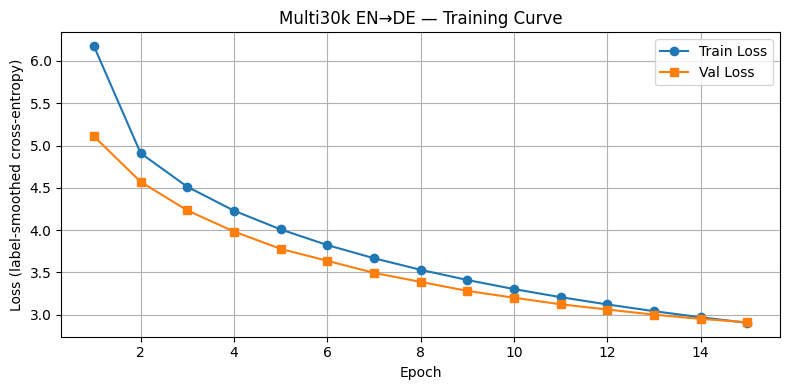

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS+1), train_losses, marker='o', label='Train Loss')
plt.plot(range(1, EPOCHS+1), val_losses,   marker='s', label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss (label-smoothed cross-entropy)")
plt.title("Multi30k EN→DE — Training Curve")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 15. Inference — Greedy Decoding
At test time, we feed `<START>` to the decoder, take the highest-probability token,  
append it, and repeat until `<END>` or `max_len` is reached.


In [ ]:
def translate(model, sentence, max_len=50):
    model.eval()
    tokens  = [src_vocab.get(w, src_vocab[UNK]) for w in sentence.lower().split()]
    src_ids = [src_vocab[START]] + tokens + [src_vocab[END]]
    src_t   = torch.tensor(src_ids).unsqueeze(0).to(DEVICE)      # (1, S)
    src_mask= make_src_mask(src_t, src_vocab[PAD])

    with torch.no_grad():
        enc_out = model.encoder(src_t, src_mask)

        tgt_ids = [tgt_vocab[START]]
        for _ in range(max_len):
            tgt_t    = torch.tensor(tgt_ids).unsqueeze(0).to(DEVICE)
            tgt_mask = make_tgt_mask(tgt_t, tgt_vocab[PAD])
            out      = model.decoder(tgt_t, enc_out, tgt_mask, src_mask)
            next_id  = out[0, -1].argmax().item()
            if next_id == tgt_vocab[END]:
                break
            tgt_ids.append(next_id)

    return " ".join(idx2tgt[i] for i in tgt_ids[1:])


# Test on samples from the test set
print(f"{'Source (EN)':45s}  {'Predicted (DE)'}")
print("-" * 90)
for i in range(10):
    src_s = test_en[i]
    pred  = translate(model, src_s)
    ref   = test_de[i]
    print(f"SRC : {src_s}")
    print(f"PRED: {pred}")
    print(f"REF : {ref}")
    print()

Source (EN)                                    Predicted (DE)
------------------------------------------------------------------------------------------
SRC : a man in an orange hat starring at something.
PRED: ein mann mit einem orangefarbenen hut schaut auf etwas an.
REF : ein mann mit einem orangefarbenen hut, der etwas anstarrt.

SRC : a boston terrier is running on lush green grass in front of a white fence.
PRED: ein <UNK> mit grünen <UNK> rennt vor einem weißen zaun.
REF : ein boston terrier läuft über saftig-grünes gras vor einem weißen zaun.

SRC : a girl in karate uniform breaking a stick with a front kick.
PRED: ein mädchen in <UNK> <UNK> einen stock vor einem <UNK>
REF : ein mädchen in einem karateanzug bricht ein brett mit einem tritt.

SRC : five people wearing winter jackets and helmets stand in the snow, with snowmobiles in the background.
PRED: fünf personen in <UNK> und mit helmen stehen im hintergrund sind <UNK>
REF : fünf leute in winterjacken und mit helmen stehen 

## 16. BLEU Score on Test Set
**BLEU** (Bilingual Evaluation Understudy) measures n-gram overlap between predicted and reference translations.  
- BLEU = 0 → no overlap  
- BLEU = 100 → perfect match  
- A score of **20-30** is considered reasonable for a small from-scratch model.


In [ ]:
def compute_bleu(model, src_sentences, ref_sentences, max_samples=500):
    from collections import Counter
    import math

    def ngrams(tokens, n):
        return [tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1)]

    def bleu_score(pred_tokens, ref_tokens, max_n=4):
        scores, weights = [], [0.25] * max_n
        brevity = min(1.0, len(pred_tokens) / max(len(ref_tokens), 1))
        for n in range(1, max_n + 1):
            pred_ng = Counter(ngrams(pred_tokens, n))
            ref_ng  = Counter(ngrams(ref_tokens,  n))
            clipped = sum(min(c, ref_ng[g]) for g, c in pred_ng.items())
            denom   = max(len(pred_tokens) - n + 1, 1)
            scores.append(clipped / denom if denom > 0 else 0)
        log_score = sum(w * math.log(s + 1e-10) for w, s in zip(weights, scores))
        return brevity * math.exp(log_score) * 100

    total, count = 0.0, 0
    for src, ref in zip(src_sentences[:max_samples], ref_sentences[:max_samples]):
        pred = translate(model, src)
        total += bleu_score(pred.split(), ref.split())
        count += 1

    return total / count


bleu = compute_bleu(model, test_en, test_de)
print(f"BLEU score on {500} test samples: {bleu:.2f}")
print()
print("Interpretation:")
print("  < 10  → barely intelligible")
print("  10-20 → gist is there, many errors")
print("  20-30 → reasonable for a small scratch model")
print("  > 30  → good quality")

BLEU score on 500 test samples: 18.63

Interpretation:
  < 10  → barely intelligible
  10-20 → gist is there, many errors
  20-30 → reasonable for a small scratch model
  > 30  → good quality


## 17. Attention Heatmap — What Is the Decoder Looking At?
We visualise the **cross-attention weights** from the last decoder layer.  
Each row = a generated German token.  
Each column = an English source token.  
Brighter = stronger attention.

Good patterns to look for:
- Diagonal alignment (word-order-preserving pairs)
- `<END>` attending to `<END>`
- Adjective-noun pairs swapping (EN noun-adj → DE adj-noun)


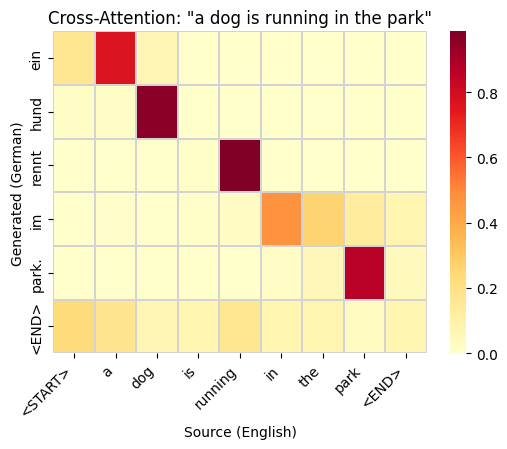

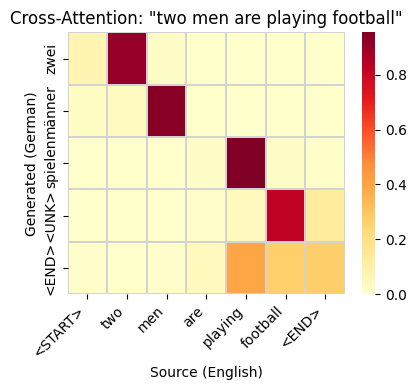

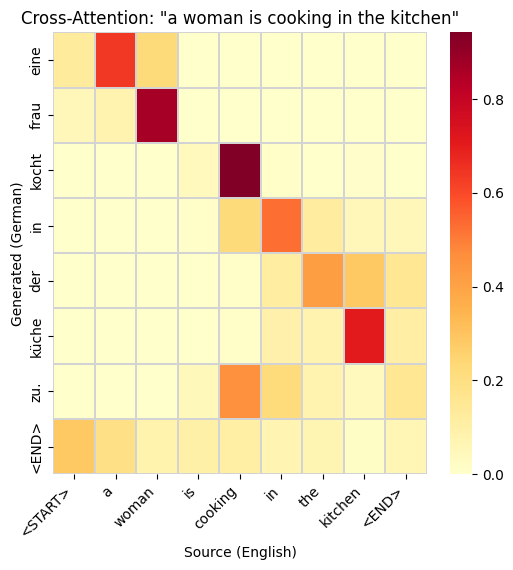

In [ ]:
def get_cross_attention(model, sentence, max_len=50):
    """Run inference and capture cross-attention from last decoder layer."""
    model.eval()
    tokens  = [src_vocab.get(w, src_vocab[UNK]) for w in sentence.lower().split()]
    src_ids = [src_vocab[START]] + tokens + [src_vocab[END]]
    src_t   = torch.tensor(src_ids).unsqueeze(0).to(DEVICE)
    src_mask= make_src_mask(src_t, src_vocab[PAD])

    src_words  = [START] + sentence.lower().split() + [END]
    pred_words = [START]

    with torch.no_grad():
        enc_out = model.encoder(src_t, src_mask)
        tgt_ids = [tgt_vocab[START]]

        for _ in range(max_len):
            tgt_t    = torch.tensor(tgt_ids).unsqueeze(0).to(DEVICE)
            tgt_mask = make_tgt_mask(tgt_t, tgt_vocab[PAD])
            _        = model.decoder(tgt_t, enc_out, tgt_mask, src_mask)
            next_id  = model.decoder.layers[-1].cross_attn.attention_weights[0, 0, -1].argmax().item()
            # actual next token from logits
            out      = model.decoder(tgt_t, enc_out, tgt_mask, src_mask)
            next_id  = out[0, -1].argmax().item()
            if next_id == tgt_vocab[END]:
                pred_words.append(END)
                break
            pred_words.append(idx2tgt[next_id])
            tgt_ids.append(next_id)

        # Capture full attention matrix for the final sequence
        tgt_t    = torch.tensor(tgt_ids).unsqueeze(0).to(DEVICE)
        tgt_mask = make_tgt_mask(tgt_t, tgt_vocab[PAD])
        model.decoder(tgt_t, enc_out, tgt_mask, src_mask)
        attn = model.decoder.layers[-1].cross_attn.attention_weights
        # attn: (1, num_heads, T, S) — average over heads
        attn_avg = attn[0].mean(dim=0).cpu().numpy()

    tgt_words = pred_words[1:]   # drop <START>
    return attn_avg[:len(tgt_words), :len(src_words)], src_words, tgt_words


def plot_attention(sentence):
    attn, src_words, tgt_words = get_cross_attention(model, sentence)

    fig, ax = plt.subplots(figsize=(len(src_words) * 0.6, len(tgt_words) * 0.6 + 1))
    sns.heatmap(attn, xticklabels=src_words, yticklabels=tgt_words,
                cmap='YlOrRd', ax=ax, linewidths=0.3, linecolor='lightgray',
                vmin=0, vmax=attn.max())
    ax.set_xlabel("Source (English)")
    ax.set_ylabel("Generated (German)")
    ax.set_title(f"Cross-Attention: \"{sentence}\"")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


# Try a few test sentences
plot_attention("a dog is running in the park")
plot_attention("two men are playing football")
plot_attention("a woman is cooking in the kitchen")

## 18. Summary & Next Steps

### What We Built
| Component | Details |
|-----------|---------|
| Dataset | Multi30k EN→DE, 29k pairs |
| Tokenisation | Word-level, vocab size 5000 |
| Architecture | 3-layer Transformer, d_model=256, 8 heads |
| Parameters | ~10M |
| Training | 15 epochs, Adam, label smoothing |
| Evaluation | BLEU score + attention heatmap |
